# **Assignment 12**

## Imports

In [6]:
import pandas as pd
import numpy as np
import os
import random
import torch
import torch.nn as nn
from sklearn.metrics import f1_score, precision_score, recall_score
from datetime import datetime
from itertools import product
from sklearn.model_selection import KFold
import torch.optim as optim
import json
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

device = torch.device("cpu")
random_seed = 42
np.random.seed(random_seed)
torch.manual_seed(random_seed)

## All necesary methods

In [7]:
def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files
    

def input_target_split_start_stop(dataframe):

    joints = [
        "head", "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot" ]

    input_col_names = []

    for joint in joints:
        input_col_names += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    X = dataframe[input_col_names].copy()
    y = dataframe[["running_video"]].copy()

    return X, y

def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined


# Function to load champion model/ best performing model
def load_champion_info(metadata_dir):
    path = os.path.join(metadata_dir, "champion_info.json")

    if not os.path.exists(path):
        return None

    try:
        with open(path, "r") as f:
            return json.load(f)
    except:
        return None

# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)


# Define Feedforward squat classifier class
class Squatclassifier(nn.Module):
    def __init__(self, input_size, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []

        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        act = activations[activation]
        prev_size = input_size

        # Hidden layers
        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(act)

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer- 1 neuron
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)
    
    def forward(self, X):
        return self.network(X)
        


# Initializes a squatclassifier model based on a configuration
def build_model(config):
    return Squatclassifier(
        input_size=config["input_size"],
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Train the model
def train_one_model(model, config, x_train, y_train, x_val, y_val, loss_fn):
    optimizer = optim.Adam(model.parameters(), lr=config["lr"])
    epochs = config["epochs"]

    best_val_f1 = 0
    best_state = None
    patience = 10
    epochs_no_improve = 0

    # reshape targets
    y_train = y_train.view(-1, 1)
    y_val = y_val.view(-1, 1)

    # Training loop (full-batch)
    for epoch in range(epochs):

        model.train()
        optimizer.zero_grad()

        logits = model(x_train)
        loss = loss_fn(logits, y_train)

        loss.backward()
        optimizer.step()

        # Validation
        model.eval()

        with torch.no_grad():
            val_logits = model(x_val)
            probs = torch.sigmoid(val_logits)
            preds = (probs > 0.5).float()

            val_f1 = f1_score(
                y_val.cpu().numpy(),
                preds.cpu().numpy()
            )

        # Early stopping on f1-score
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = model.state_dict()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            break

    return best_val_f1, best_state

## Load in Mediapipe data (for selected videos)

In [8]:
data_folder = "../../MainProject/data/mediapipe_removed_non_squat"

training_prop = 0.9
validation_prop = 0
train_files, test_files = split_csvfiles(data_folder, random_seed, training_prop, validation_prop)

# Load in combined dataframe of all the files kept in the specific split
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)

# Split input (x, y, z) and target (running_video)
x_train, y_train = input_target_split_start_stop(train_data)
x_test, y_test = input_target_split_start_stop(test_data)

# Normalize data with the training scale
scaler = StandardScaler()
x_train_np = x_train.values
x_test_np = x_test.values

x_train_scaled = scaler.fit_transform(x_train_np)
x_test_scaled = scaler.transform(x_test_np)  # use same scaler

# Convert to tensors for the 
x_train = torch.tensor(x_train_scaled, dtype=torch.float32).to(device)
y_train = torch.tensor(y_train.values, dtype=torch.float32).to(device)
x_test = torch.tensor(x_test_scaled, dtype=torch.float32).to(device)
y_test = torch.tensor(y_test.values, dtype=torch.float32).to(device)


## Load in champion model

In [11]:
metadata_path_mp = "../binary_classificator_models/on_mediapipe/metadata"

champion_info_mp = load_champion_info(metadata_path_mp)

best_config_mp = champion_info_mp["hyperparameters"]

print("\nChampion config loaded for Mediapipe data")
print(best_config_mp)


Champion config loaded for Mediapipe data
{'layers': [256, 128, 32], 'lr': 0.005, 'dropout': 0.1, 'activation': 'relu', 'epochs': 200, 'input_size': 39}


## Retrain on MP data (bad videos removed)

In [17]:
final_model = build_model(best_config_mp)

# Make split for the retraining s.t model isn't overfitted to the training data
x_tr, x_val, y_tr, y_val = train_test_split(x_train, y_train, test_size=0.1, random_state=42)

# Retrain best config from the cross validation gridsearch
_, best_state = train_one_model(final_model, best_config_mp, x_tr, y_tr, x_val, y_val, loss_fn = nn.BCEWithLogitsLoss())

## Evaluate on test

F1: 0.9310950614874097
Precision: 0.9040940106141016
Recall: 0.959758551307847
Accuracy: 90.2297%


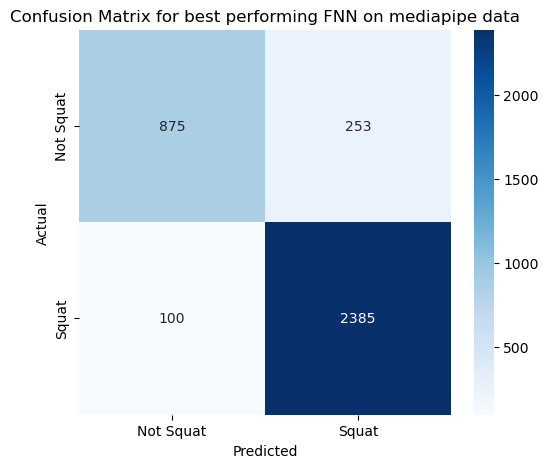

In [19]:
# Load weights from re-training
final_model.load_state_dict(best_state)

# Evaluate against test set
final_model.eval()
with torch.no_grad():
    logits = final_model(x_test.to(device))
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()

    f1 = f1_score(y_test.cpu(), preds.cpu())
    precision = precision_score(y_test.cpu(), preds.cpu())
    recall = recall_score(y_test.cpu(), preds.cpu())
    accuracy = accuracy_score(y_test.cpu(), preds.cpu())

    cm = confusion_matrix(y_test.cpu(), preds.cpu())

print(f"F1: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"Accuracy: {round(accuracy * 100, 4)}%")


# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Squat", "Squat"],
            yticklabels=["Not Squat", "Squat"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for best performing FNN on mediapipe data")
plt.show()

## File by file (video by video) evaluation

In [ ]:
def file_by_file_eval(datafolder, model, device="cpu"):
    model.eval()
    errors_per_file = []

    with torch.no_grad():
        for file in os.listdir(datafolder):
            if not file.endswith("csv"):
                continue
            
            # Get each filepath and open as dataframe
            filepath = os.path.join(datafolder, file)
            df = pd.read_csv(filepath)

            # Split input (x, y, z) from target (running_video)
            X, y = input_target_split_start_stop(df)

            X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
            y_tensor = torch.tensor(y, dtype=torch.float32).to(device)

            # Forward pass
            logits = model(X_tensor)
            probs = torch.sigmoid(logits)
            y_preds = (probs > 0.5).float()

            # Count misclassified frames
            errors = (y_preds != y_tensor).sum().item()
            errors_per_file.append(errors)
    
    errors_per_file = np.array(errors_per_file)

    mean_errors = errors_per_file.mean()
    std_errors = errors_per_file.std()

    return mean_errors, std_errors